# Pneumonia Detection from Chest X-Ray Images Using CNN

## Objective

The objective of this project is to develop a Convolutional Neural
Network (CNN) for classifying chest X-ray images into two categories:

- NORMAL
- PNEUMONIA

The project includes exploratory data analysis, image preprocessing,
CNN model development, model training, evaluation, and visualization
of model predictions.

### Student Information

**Name:** 
**Student ID:** 


In [1]:
#Import Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Dataset

This project uses the **Chest X-Ray Images (Pneumonia)** dataset available on Kaggle. The dataset contains chest X-ray images classified into two categories: **NORMAL** and **PNEUMONIA**.

**Dataset Source:** Paul Mooney, *Chest X-Ray Images (Pneumonia)*, Kaggle.  
https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

In [2]:
#make sure Python can actually see the images

print(os.listdir("chest_xray"))


['.DS_Store', 'test', 'train']


In [3]:
print("Training classes:", os.listdir("chest_xray/train"))
print("Testing classes:", os.listdir("chest_xray/test"))

Training classes: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
Testing classes: ['.DS_Store', 'NORMAL', 'PNEUMONIA']


In [23]:
# Understand the dataset

train_normal = len([
    f for f in os.listdir("chest_xray/train/NORMAL")
    if not f.startswith(".")
])

train_pneumonia = len([
    f for f in os.listdir("chest_xray/train/PNEUMONIA")
    if not f.startswith(".")
])

test_normal = len([
    f for f in os.listdir("chest_xray/test/NORMAL")
    if not f.startswith(".")
])

test_pneumonia = len([
    f for f in os.listdir("chest_xray/test/PNEUMONIA")
    if not f.startswith(".")
])

print("Training images:")
print("NORMAL:", train_normal)
print("PNEUMONIA:", train_pneumonia)

print("\nTesting images:")
print("NORMAL:", test_normal)
print("PNEUMONIA:", test_pneumonia)

Training images:
NORMAL: 1349
PNEUMONIA: 3883

Testing images:
NORMAL: 234
PNEUMONIA: 390


In [5]:
train_dir = "chest_xray/train"
test_dir = "chest_xray/test"

In [6]:
# Check class distribution in the training dataset

normal_count = len([
    file for file in os.listdir(os.path.join(train_dir, "NORMAL"))
    if not file.startswith(".")
])

pneumonia_count = len([
    file for file in os.listdir(os.path.join(train_dir, "PNEUMONIA"))
    if not file.startswith(".")
])

print("Training Class Distribution")
print("---------------------------")
print("NORMAL:", normal_count)
print("PNEUMONIA:", pneumonia_count)
print("Total:", normal_count + pneumonia_count)

Training Class Distribution
---------------------------
NORMAL: 1349
PNEUMONIA: 3883
Total: 5232


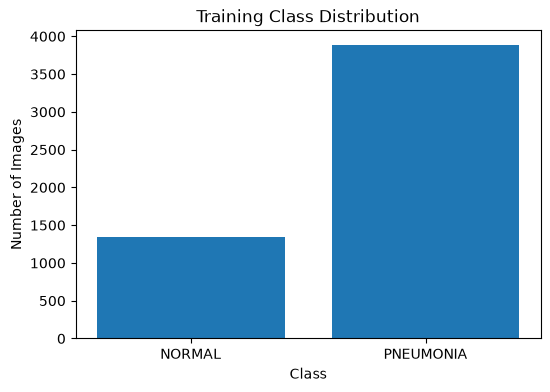

In [7]:
# Visualize training class distribution

classes = ["NORMAL", "PNEUMONIA"]
counts = [normal_count, pneumonia_count]

plt.figure(figsize=(6, 4))
plt.bar(classes, counts)

plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

### Class Distribution Analysis

The training dataset contains 5,232 chest X-ray images, including 1,349 NORMAL images and 3,883 PNEUMONIA images. This shows that the dataset is imbalanced, with substantially more pneumonia images than normal images. Approximately 74% of the training images belong to the PNEUMONIA class, while about 26% belong to the NORMAL class.

This class imbalance may influence the CNN to become more biased toward predicting the majority PNEUMONIA class. Therefore, class-specific evaluation metrics such as precision, recall, F1-score, and the confusion matrix are important in addition to overall accuracy.

In [8]:
#convert the X-ray images into TensorFlow datasets that the CNN can train on

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=["NORMAL", "PNEUMONIA"],
    validation_split=0.2,
    subset="training",
    seed=SEED,
    shuffle=True
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=["NORMAL", "PNEUMONIA"],
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=["NORMAL", "PNEUMONIA"],
    shuffle=False
)

print("Classes:", train_dataset.class_names)

Found 5232 files belonging to 2 classes.
Using 4186 files for training.
Found 5232 files belonging to 2 classes.
Using 1046 files for validation.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


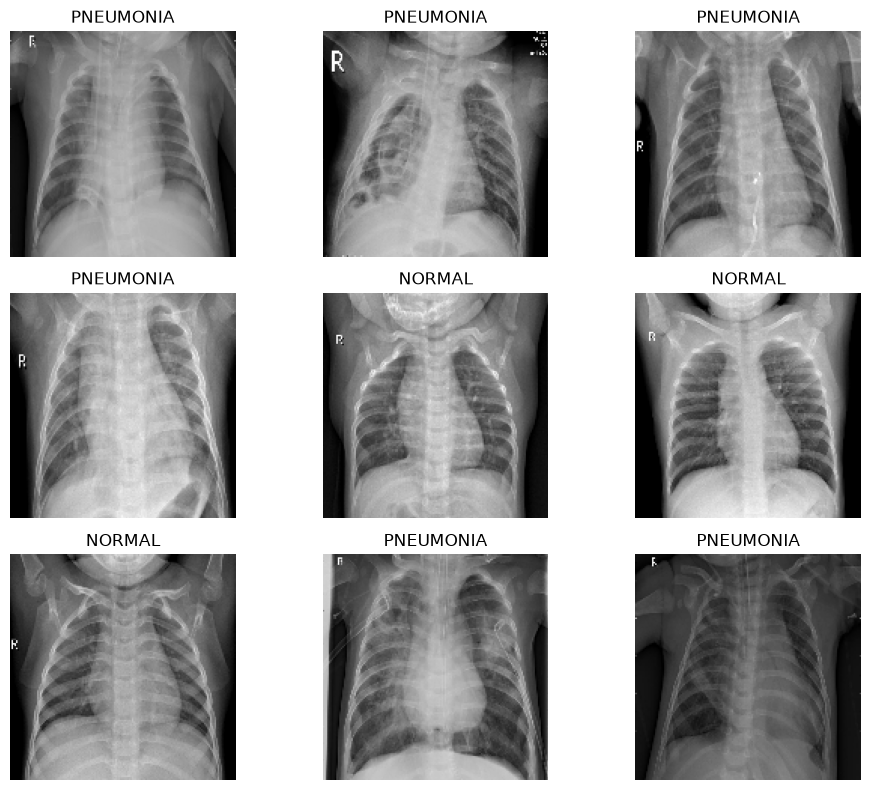

In [9]:
#visually inspect the data before normalisation

plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")
        plt.title("PNEUMONIA" if labels[i].numpy()[0] == 1 else "NORMAL")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
#normalize all three datasets

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Training, validation, and test datasets are ready.")

Training, validation, and test datasets are ready.


### Data Preprocessing

All chest X-ray images were resized to 150 × 150 pixels during dataset loading to provide a consistent input size for the CNN. The pixel values were then normalized from the original range of 0–255 to 0–1 using a rescaling layer. Normalization helps provide a consistent input scale for neural network training.

The original training data was divided into 80% training data and 20% validation data, while the provided test dataset was kept separate and used only for final model evaluation.

In [11]:
#Check the pixel values
for images, labels in train_dataset.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())
    print("Image shape:", images.shape)
    

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Image shape: (32, 150, 150, 3)


In [12]:
#CNN
model = tf.keras.Sequential([
    tf.keras.Input(shape=(150, 150, 3)),

    # Convolutional Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

### CNN Model Architecture

The CNN consists of three convolutional blocks. The convolutional layers use 32, 64, and 128 filters with 3 × 3 kernels and ReLU activation functions to learn increasingly complex features from the chest X-ray images. Each convolutional layer is followed by a MaxPooling2D layer, which reduces the spatial dimensions of the feature maps.

The extracted feature maps are flattened and passed to a fully connected Dense layer with 128 neurons and ReLU activation. Dropout layers with a rate of 0.5 are included to reduce overfitting by randomly deactivating neurons during training.

The final layer contains one neuron with a sigmoid activation function because this is a binary classification problem, where the model predicts either NORMAL or PNEUMONIA.

In [13]:
#compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")


Model compiled successfully!


### Model Compilation

The model was compiled using the Adam optimizer, binary cross-entropy loss, and accuracy as the evaluation metric. Adam was used to update the model weights during training. Binary cross-entropy is appropriate because the task involves binary classification between NORMAL and PNEUMONIA. Accuracy was monitored to measure the proportion of correctly classified images.

In [14]:
#train

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10


C:\Users\mygal\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.8402 - loss: 0.3520 - val_accuracy: 0.9771 - val_loss: 0.0671
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.9405 - loss: 0.1533 - val_accuracy: 0.9685 - val_loss: 0.0766
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9613 - loss: 0.1071 - val_accuracy: 0.9751 - val_loss: 0.0599
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9623 - loss: 0.1073 - val_accuracy: 0.9579 - val_loss: 0.1010
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9682 - loss: 0.0920 - val_accuracy: 0.9799 - val_loss: 0.0542
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9697 - loss: 0.0884 - val_accuracy: 0.9799 - val_loss: 0.0510
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.9783 - loss: 0.0691 - val_accuracy: 0.9790 - val_loss: 0.0460
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9778 - loss: 0.0660 - val_accuracy: 0.979

### Model Training

The CNN was trained for 10 epochs using the training dataset, while the validation dataset was used to monitor the model's performance on data not used to update the model weights.

During training, the training accuracy increased and the training loss decreased, indicating that the model was learning features from the chest X-ray images. Validation accuracy and validation loss were also monitored during each epoch to assess how well the model generalized beyond the training data.

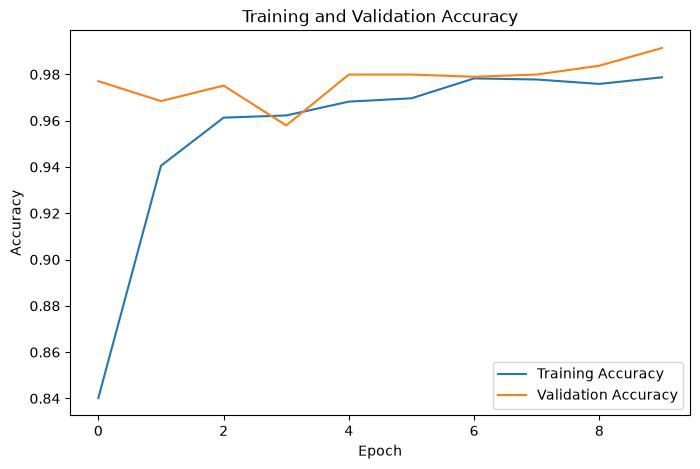

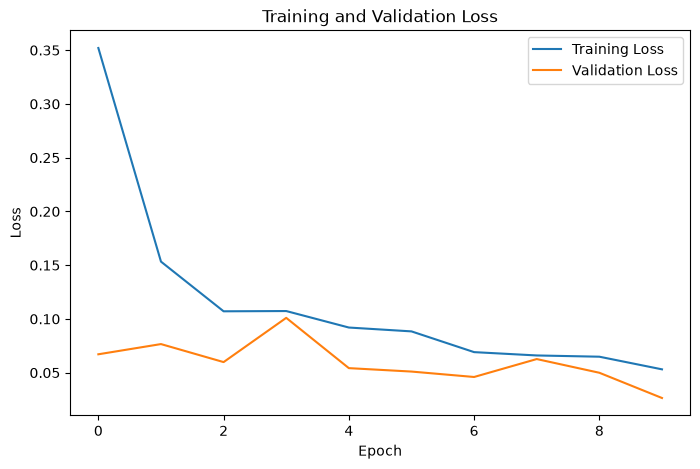

In [15]:
#Plot the training history

import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Training and Validation Performance

The training accuracy increased steadily across the 10 epochs, while the training loss decreased, showing that the CNN successfully learned patterns from the training images.

The validation accuracy remained high and generally followed the training accuracy. The validation loss also remained relatively low, although some fluctuations occurred between epochs. The training and validation curves did not show a large sustained separation by the final epochs, suggesting that severe overfitting was not evident from the validation curves alone.

However, performance on the separate test dataset must also be considered to determine how well the model generalizes to completely unseen images.

In [16]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 459ms/step - accuracy: 0.7420 - loss: 1.8043
Test Loss: 1.8043
Test Accuracy: 0.7420
Test Accuracy (%): 74.20%


### Test Set Evaluation

The trained CNN achieved a test accuracy of 74.20% on the 624 test images, with a test loss of 1.8043. The test accuracy is considerably lower than the training and validation accuracies.

This difference indicates that although the model performed very well on the training and validation data, its performance did not generalize equally well to the separate test dataset. Therefore, accuracy alone is not sufficient to understand the model's performance, and class-specific metrics such as precision, recall, F1-score, and the confusion matrix are examined below.

In [17]:
# Generate predictions on the test dataset

y_pred_prob = model.predict(test_dataset)

# Convert probabilities to class predictions
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Number of predictions:", len(y_pred))
print("First 10 predictions:", y_pred[:10])

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 350ms/step
Number of predictions: 624
First 10 predictions: [0 1 1 1 1 1 0 1 1 1]


In [18]:
# Get the true labels from the test dataset

y_true = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy().flatten())

y_true = np.array(y_true).astype(int)

print("Number of true labels:", len(y_true))
print("First 10 true labels:", y_true[:10])

Number of true labels: 624
First 10 true labels: [0 0 0 0 0 0 0 0 0 0]


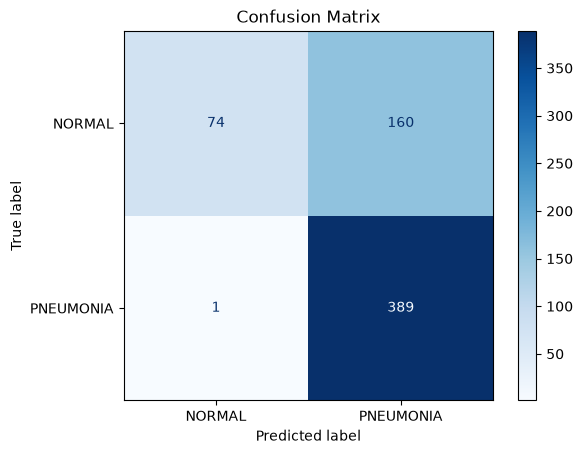

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Analysis

The confusion matrix provides a detailed view of the model's classification performance:

- 74 NORMAL X-rays were correctly classified as NORMAL.
- 160 NORMAL X-rays were incorrectly classified as PNEUMONIA.
- 1 PNEUMONIA X-ray was incorrectly classified as NORMAL.
- 389 PNEUMONIA X-rays were correctly classified as PNEUMONIA.

The model successfully detected almost all pneumonia cases, but it incorrectly classified a large number of normal X-rays as pneumonia. This indicates that the model has a tendency to predict the PNEUMONIA class more frequently.

One possible contributing factor is the class imbalance in the training dataset, which contains 3,883 PNEUMONIA images compared with only 1,349 NORMAL images.

In [20]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.32      0.48       234
   PNEUMONIA       0.71      1.00      0.83       390

    accuracy                           0.74       624
   macro avg       0.85      0.66      0.65       624
weighted avg       0.81      0.74      0.70       624



### Classification Report Analysis

The classification report shows that the model performs differently for the two classes.

For the PNEUMONIA class, the model achieved a precision of 0.71, recall of 1.00, and F1-score of 0.83. The very high recall indicates that the model successfully identified almost all pneumonia cases in the test dataset.

For the NORMAL class, the model achieved a precision of 0.99, recall of 0.32, and F1-score of 0.48. Although predictions classified as NORMAL were usually correct, the low recall shows that many actual NORMAL images were incorrectly classified as PNEUMONIA.

The overall test accuracy was approximately 74%. These results show why accuracy alone does not fully describe the model's performance, particularly when the classes are imbalanced.

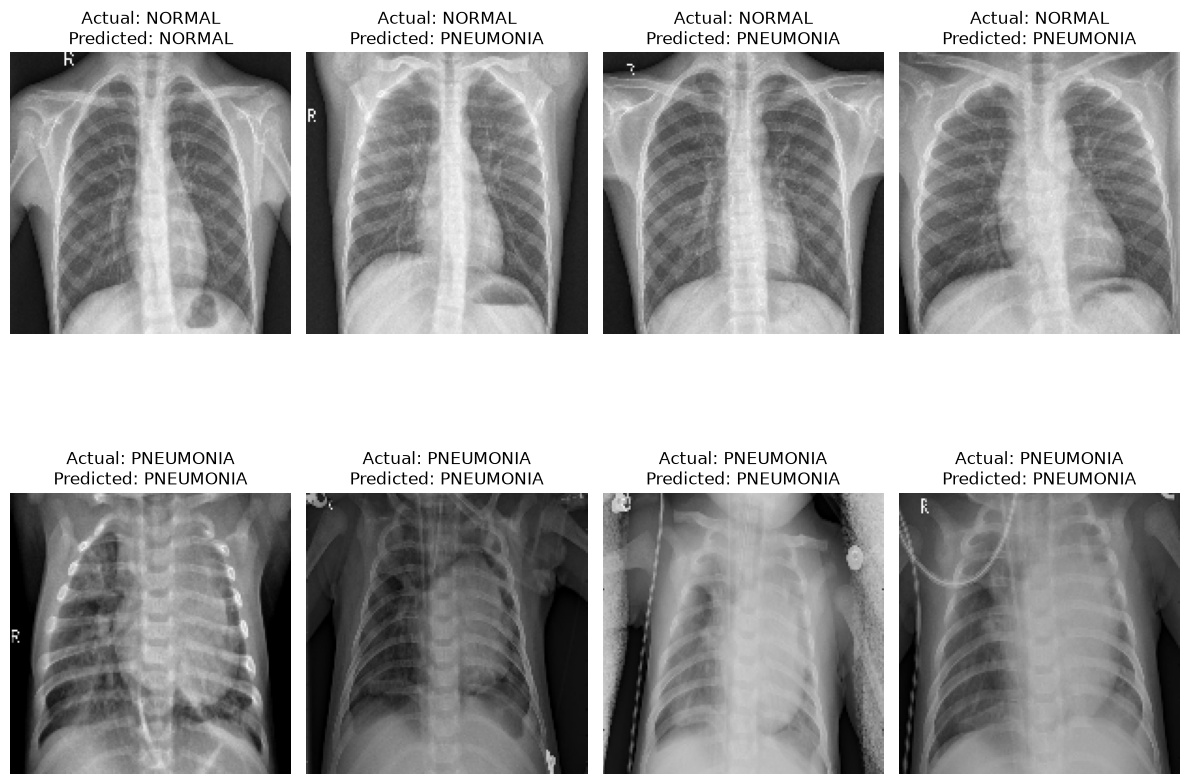

In [21]:
# Display predictions from both NORMAL and PNEUMONIA classes

plt.figure(figsize=(12, 10))

normal_count = 0
pneumonia_count = 0
plot_index = 1

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    for i in range(len(images)):
        actual = int(labels[i].numpy()[0])

        # Select 4 NORMAL and 4 PNEUMONIA images
        if (actual == 0 and normal_count < 4) or (actual == 1 and pneumonia_count < 4):

            true_label = "NORMAL" if actual == 0 else "PNEUMONIA"

            predicted_label = (
                "PNEUMONIA"
                if predictions[i][0] > 0.5
                else "NORMAL"
            )

            plt.subplot(2, 4, plot_index)
            plt.imshow(images[i].numpy())

            plt.title(
                f"Actual: {true_label}\n"
                f"Predicted: {predicted_label}"
            )

            plt.axis("off")

            if actual == 0:
                normal_count += 1
            else:
                pneumonia_count += 1

            plot_index += 1

        if normal_count == 4 and pneumonia_count == 4:
            break

    if normal_count == 4 and pneumonia_count == 4:
        break

plt.tight_layout()
plt.show()

### Sample Prediction Analysis

The sample predictions provide a visual comparison between the true labels and the CNN's predicted labels for chest X-ray images from both classes.

The displayed examples show that the model correctly identifies the PNEUMONIA samples shown, while some NORMAL samples are incorrectly predicted as PNEUMONIA. This is consistent with the confusion matrix and classification report, which showed very high recall for PNEUMONIA but considerably lower recall for NORMAL.

These predictions further demonstrate the model's tendency to classify images as PNEUMONIA more frequently than NORMAL.

In [22]:
# Final model performance summary

print("CNN Model Evaluation Summary")
print("-" * 35)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print()
print("Confusion Matrix:")
print(cm)

CNN Model Evaluation Summary
-----------------------------------
Test Accuracy: 74.20%
Test Loss: 1.8043

Confusion Matrix:
[[ 74 160]
 [  1 389]]


## Conclusion

A Convolutional Neural Network (CNN) was developed to classify chest X-ray images as NORMAL or PNEUMONIA. The images were resized, normalized, and divided into training, validation, and test datasets. The CNN used three convolutional blocks with ReLU activation and max pooling, followed by dropout and fully connected layers for classification.

On the independent test dataset, the final model achieved an accuracy of 74.20% with a test loss of 1.8043.

The model showed strong performance on the training and validation datasets. However, its performance on the independent test dataset was lower, indicating that the model did not generalize equally well to unseen test images.

The evaluation also showed a large difference between the two classes. The model detected most PNEUMONIA cases but incorrectly classified many NORMAL images as PNEUMONIA. The imbalance in the training dataset, which contains substantially more PNEUMONIA images than NORMAL images, may have contributed to this behavior.

### Limitations and Possible Improvements

The model could potentially be improved by addressing the class imbalance using techniques such as class weighting or data augmentation. Additional improvements could include tuning the CNN architecture and hyperparameters, using early stopping, and experimenting with transfer learning using a pre-trained CNN model.

Overall, the project demonstrates how a CNN can be used for medical image classification while also showing the importance of evaluating class-specific performance rather than relying only on overall accuracy.